# MACH 02 · Spectroscopic completeness vs. magnitude

Spectroscopic completeness f_spec(r) of each MACH cluster within R200, split by redshift source (SDSS, SDSS+DESI, all), and the magnitude down to which the cumulative completeness stays above the threshold. The per-cluster limits are written to `../SMF/MACH_1dspec_limit.csv` and used by the SMF notebooks.

**Inputs** (not included): `DATA/MACH_PHOT/MACH_photcat_3R200.csv`, `DATA/MACH_PHOT/AllHeCS_VAC_updated.csv`

**Outputs**: `../SMF/MACH_1dspec_limit.csv`, `FIGURE/IMAGES/Figure2.pdf`

In [1]:
# ============================================================================
# Setup
# ============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from astropy.cosmology import LambdaCDM

# Cosmology used throughout this project
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

# Matplotlib style shared by the notebooks of this repository
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    'lines.linewidth': 2,
    'axes.linewidth': 4,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Show every column when a DataFrame is displayed
pd.set_option('display.max_columns', None)

# The nine MACH clusters
MACHLIST = ['A2245', 'A1767', 'A2244', 'A1831', 'A2034', 'A7', 'A2255', 'A2029', 'A2065']

# Repository root, located relative to this notebook; DATA/ and FIGURE/ hang off it
MAINPATH = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
FIGUREPATH = f"{MAINPATH}/FIGURE/IMAGES"

%config InlineBackend.figure_format = 'retina'

In [2]:
# Define file paths
mach_file = f"{MAINPATH}/DATA/MACH_PHOT/MACH_photcat_3R200.csv"
hecs_vac_file = f"{MAINPATH}/DATA/MACH_PHOT/AllHeCS_VAC_updated.csv"

# Load datasets
mach_data = pd.read_csv(mach_file)
hecs_vac_data = pd.read_csv(hecs_vac_file)

# Apply extinction corrections
mach_data['cmodelMag_r_0'] = mach_data['cmodelMag_r'] - mach_data['extinction_r']
mach_data['cmodelMag_g_0'] = mach_data['cmodelMag_g'] - mach_data['extinction_g']

# Objects within R200
df = mach_data.loc[mach_data['Rcl/R200'] <= 1.0].copy()

In [28]:
# Parameters for easy adjustment
RCL_LIMIT = 1.0
R_MAG_LIMIT = 20.0

num_with_specz = len(
    mach_data[
        (mach_data['Z_TOT_Z'] != -99.0) &
        (mach_data['Rcl/R200'] <= RCL_LIMIT) &
        (mach_data['cmodelMag_r_0'] <= R_MAG_LIMIT)
    ]
)
num_total = len(
    mach_data[
        (mach_data['Rcl/R200'] <= RCL_LIMIT) &
        (mach_data['cmodelMag_r_0'] <= R_MAG_LIMIT)
    ]
)
completeness = num_with_specz / num_total if num_total > 0 else float('nan')
print(f"Spectroscopic completeness (Rcl/R200 <= {RCL_LIMIT}, r <= {R_MAG_LIMIT}): {completeness:.4f}")

# Apparent magnitude of M_r = -18.34 at z = 0.1 (Planck18 cosmology, as in the referenced completeness limit)
from astropy.cosmology import Planck18

z = 0.1
M = -17.337 - 1.0   # absolute magnitude

dist_mod = Planck18.distmod(z).value

# Convert to apparent magnitude
m = M + dist_mod

print(f"Absolute magnitude M = {M} at z={z} corresponds to apparent magnitude m = {m:.3f}")

Spectroscopic completeness (Rcl/R200 <= 1.0, r <= 20.0): 0.9646
Absolute magnitude M = -18.337 at z=0.1 corresponds to apparent magnitude m = 20.050


# 1. Completeness of all nine clusters (Figure 2)

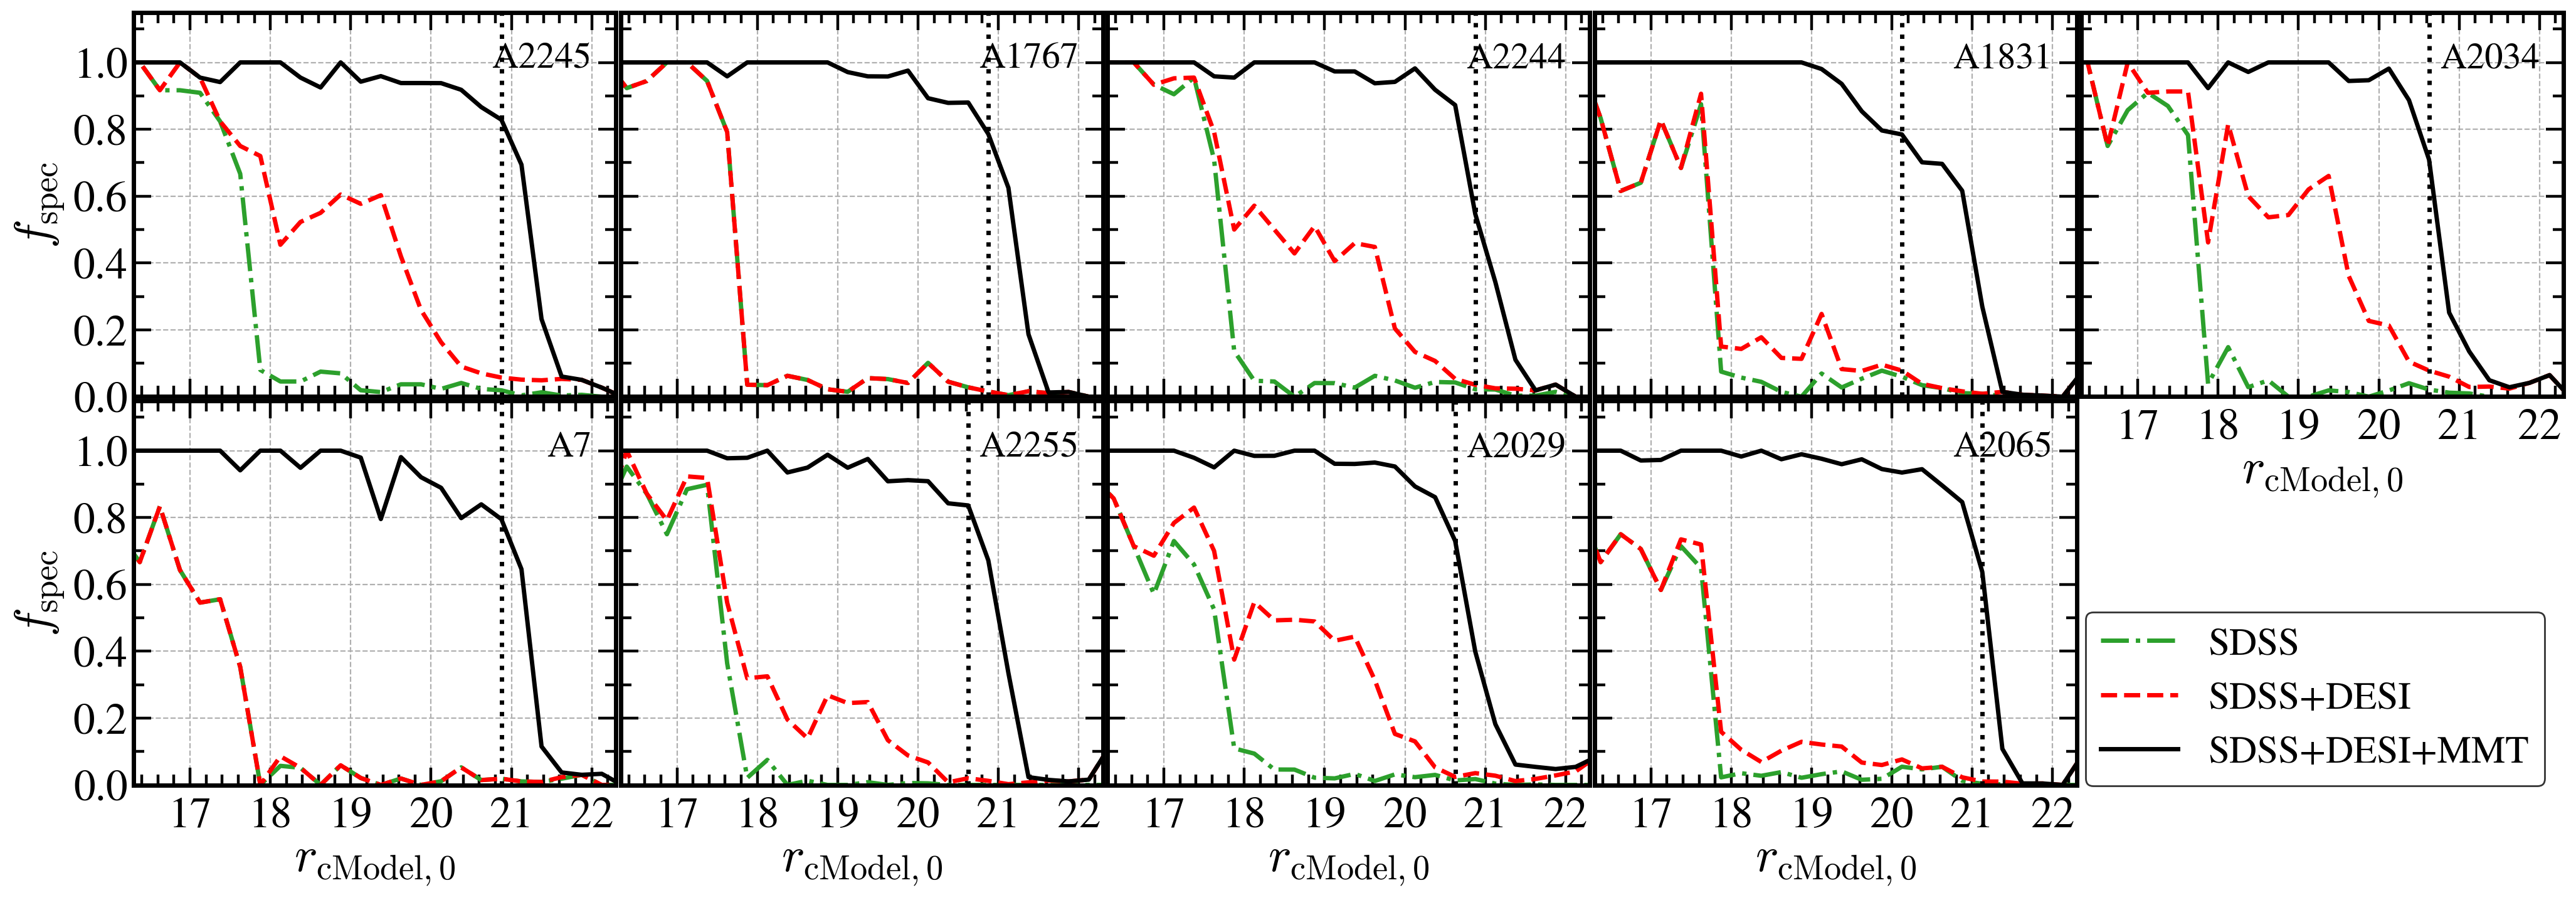

MACH 1D spec completeness <20.5 is 0.938


In [10]:
# Threshold: Cumulative completeness level (for vertical dotted line)
THRESH = 0.88

# Prepare a 2x5 grid for cluster subplots
fig, axs = plt.subplots(
    2, 5, figsize=(25, 8), 
    gridspec_kw={'wspace': 0.01, 'hspace': 0.01}
)
axs = axs.flatten()  # Flatten to 1D for easy indexing

# List to collect faintest bins meeting threshold for each cluster
exceed_bin_data = []

# Loop over all cluster IDs
for i, cluster_id in enumerate(MACHLIST):
    # Select data for the current cluster
    cd = df[df['CLID'] == cluster_id]

    # Get cluster redshift from hecs_vac_data (for optional annotation)
    zval = hecs_vac_data.loc[hecs_vac_data['CLID'] == cluster_id, 'Z']
    z_cl = zval.values[0] if len(zval) else np.nan

    # --- Bin definitions ---
    bin_width = 0.25
    mag_min = np.floor(cd['cmodelMag_r_0'].min())
    mag_max = np.ceil(cd['cmodelMag_r_0'].max())
    bin_edges = np.arange(mag_min, mag_max + bin_width, bin_width)
    bins = pd.cut(cd['cmodelMag_r_0'], bin_edges, include_lowest=True)
    categories = bins.cat.categories
    mids = categories.mid  # Bin centers

    # --- Count galaxies per magnitude bin ---
    total = cd.groupby(bins).size().reindex(categories, fill_value=0)

    # Count galaxies with *any* spec-z (Z_TOT_Z) per bin (black curve)
    all_spec = (
        cd[cd['Z_TOT_Z'] != -99.0]
        .groupby(bins).size()
        .reindex(categories, fill_value=0)
    )
    f_all = (all_spec / total.replace(0, np.nan)).fillna(0)

    # Count galaxies with SDSS spec-z (green curve)
    sdss_spec = (
        cd[cd['Z_SDSS_Z'] != -99.0]
        .groupby(bins).size()
        .reindex(categories, fill_value=0)
    )
    f_sdss = (sdss_spec / total.replace(0, np.nan)).fillna(0)

    # Count galaxies with SDSS or DESI spec-z (red dashed curve)
    sdz = cd[(cd['Z_SDSS_Z'] != -99.0) | (cd['Z_DESI_Z'] != -99.0)]
    sdz_spec = sdz.groupby(bins).size().reindex(categories, fill_value=0)
    f_sdz = (sdz_spec / total.replace(0, np.nan)).fillna(0)

    # --- Cumulative completeness (black curve) ---
    # Cumulative counts, from bright to faint
    cum_total = total.cumsum()
    cum_all_spec = all_spec.cumsum()
    cum_fraction = (cum_all_spec / cum_total.replace(0, np.nan)).fillna(0)
    cum_fraction.index = mids  # Use bin centers as index

    # Find the faintest bin where cumulative fraction >= THRESH
    if np.any(cum_fraction.values >= THRESH):
        exceed_mid = mids[cum_fraction.values >= THRESH].max()
    else:
        exceed_mid = None

    # Save this value for output table
    exceed_bin_data.append({"TARGET": cluster_id, "exceed_bin": exceed_mid})

    # --- Plotting ---
    ax = axs[i]

    # Plot SDSS fraction (green dash-dot)
    ax.plot(mids, f_sdss, color='C2', linestyle='-.', lw=2.5, label='SDSS')
    # Plot SDSS+DESI fraction (red dashed)
    ax.plot(mids, f_sdz, color='red', linestyle='--', lw=2.5, label='SDSS+DESI')
    # Plot all-spec fraction (black)
    ax.plot(mids, f_all, color='black', linestyle='-', lw=2.5, label='SDSS+DESI+MMT')

    # Draw vertical dotted line at the completeness threshold location
    if exceed_mid is not None and np.isfinite(exceed_mid):
        ax.axvline(exceed_mid, color='black', linestyle=':', linewidth=2.5)
        # Optionally display the value: 
        # ax.text(exceed_mid, 1.05, f'{exceed_mid:.2f}', rotation=90, ha='right', va='bottom', fontsize=10, color='black')

    # --- Axis formatting ---
    ax.set_xlim(16.3, 22.3)
    ax.set_ylim(0, 1.15)
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.xaxis.set_minor_locator(MultipleLocator(0.2))
    ax.yaxis.set_major_locator(MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(MultipleLocator(0.1))
    ax.grid(which='major', linestyle='--', linewidth=0.8)
    ax.tick_params(which='both', top=True, right=True)
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)

    # Cluster ID annotation in each panel
    ax.text(
        0.95, 0.92, cluster_id, transform=ax.transAxes,
        fontsize=21, va='top', ha='right'
    )

    # Optionally, show the cluster redshift:
    # if not np.isnan(z_cl):
    #     ax.text(
    #         0.75, 0.81, f"$z_\\mathrm{{cl}}={z_cl:.3f}$",
    #         transform=ax.transAxes, fontsize=16, va='top'
    #     )

    # Y-labels for leftmost panels, x-labels for the bottom row
    if i in (0, 5):
        ax.set_ylabel('$f_{\\rm spec}$', fontsize=28)
    else:
        ax.set_yticklabels([])
    if i >= 4:  # Only bottom row panels
        ax.set_xlabel('$r_{\\rm cModel,0}$', fontsize=28)
    else:
        ax.set_xticklabels([])

# Delete unused panels if MACHLIST has <10 clusters
for j in range(len(MACHLIST), len(axs)):
    fig.delaxes(axs[j])

# Draw legend outside the grid, using handles/labels from the first axis
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    bbox_to_anchor=(0.90, 0.09),
    loc='lower right',
    ncol=1,
    fontsize=22,
    frameon=True,
    edgecolor='black',
    markerscale=6
)

plt.tight_layout()
plt.savefig(f"{MAINPATH}/FIGURE/IMAGES/Figure2.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Create DataFrame of faintest bins exceeding the completeness threshold
exceed_bin_df = pd.DataFrame(exceed_bin_data)

# Save exceed_bin_df to CSV
exceed_bin_df.to_csv('../SMF/MACH_1dspec_limit.csv', index=False)

# Calculate and print MACH 1D spec completeness <20.5
mag_cut_df = df[df['cmodelMag_r_0'] < 20.5]
spec_valid_mask = mag_cut_df['Z_TOT_Z'] != -99
spec_completeness = spec_valid_mask.sum() / len(mag_cut_df)
print(f"MACH 1D spec completeness <20.5 is {spec_completeness:.3f}")

# 2. Single-cluster version (for presentations)

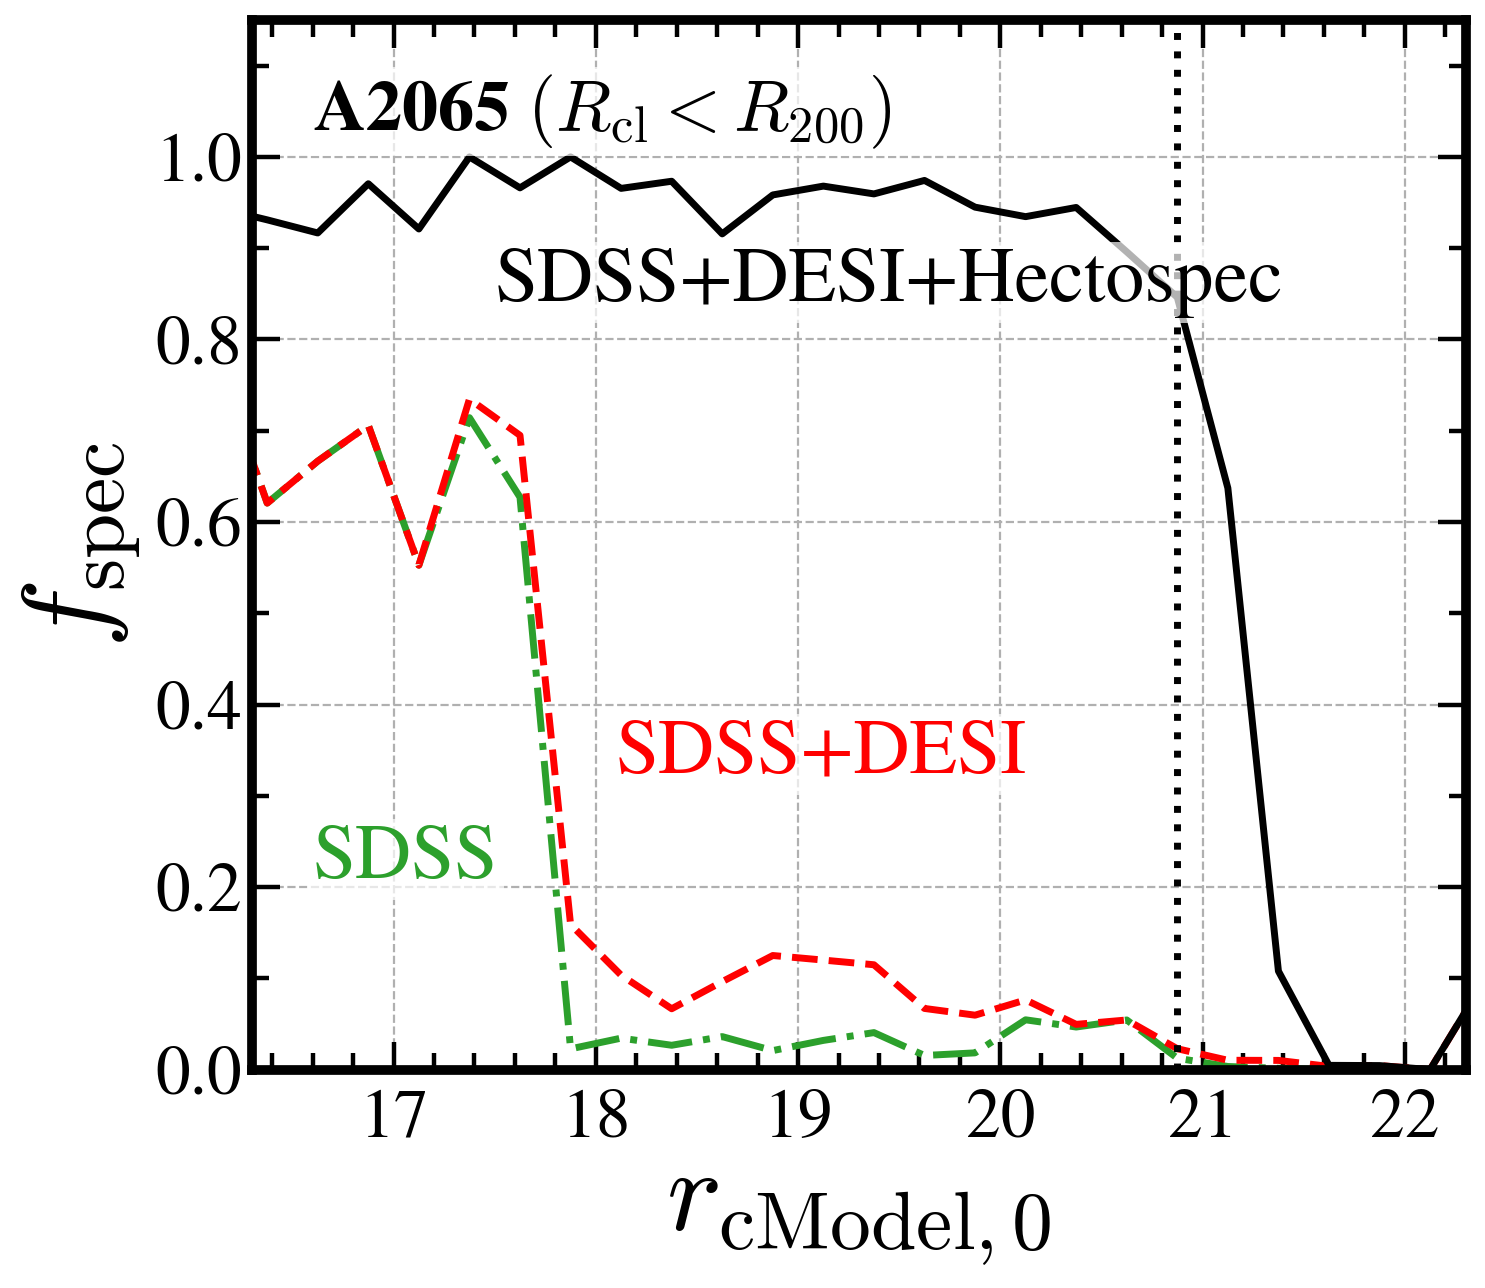

In [4]:
# ==============================
# CONFIGURATION
# ==============================

THRESH = 0.90                          # Completeness threshold (fraction)
TARGET = "A2065"                       # Cluster ID to plot
SAVE_DIR = FIGUREPATH                  # Directory for the optional PNG export

# Label positions in axes fraction (for pretty placement)
target_label_pos = (0.05, 0.95)      # Cluster label location
sdss_label_pos = (0.05, 0.20)        # "SDSS" label location
sdz_label_pos  = (0.30, 0.30)        # "SDSS+DESI" label location
all_label_pos  = (0.20, 0.75)        # "SDSS+DESI+Hectospec" label location

# Font size and style configs
label_fontsize   = 28
target_fontsize  = 26
use_bbox         = True
bbox_kwargs      = dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2.0) if use_bbox else None

# ==============================
# DATA SELECTION & SAFETY CHECK
# ==============================

# Filter relevant cluster data for plotting
cd = df[df["CLID"] == TARGET].copy()
if cd.empty:
    raise ValueError(f"No rows found in df for CLID == '{TARGET}'")

# Optionally, retrieve redshift info from hecs_vac_data, if present
z_val_series = hecs_vac_data.loc[hecs_vac_data["CLID"] == TARGET, "Z"]
z_cluster = z_val_series.values[0] if len(z_val_series) else np.nan

# ==============================
# BINNING SETUP
# ==============================

bin_width = 0.25
mag_min = float(np.floor(cd["cmodelMag_r_0"].min()))
mag_max = float(np.ceil(cd["cmodelMag_r_0"].max()))
edges = np.arange(mag_min, mag_max + bin_width, bin_width)

# Use pd.cut to bin data; get bin categories and bin centers (for plotting)
bins = pd.cut(cd["cmodelMag_r_0"], edges, include_lowest=True)
categories = bins.cat.categories
bin_mids = categories.mid

# ==============================
# COMPUTE FRACTIONS IN BINS
# ==============================

# Total counts per bin (all galaxies)
total_counts = cd.groupby(bins).size().reindex(categories, fill_value=0)

# All spectra (SDSS+DESI+MMT/Hectospec): valid if Z_TOT_Z != -99
all_spec_counts = (
    cd[cd["Z_TOT_Z"] != -99.0]
    .groupby(bins).size()
    .reindex(categories, fill_value=0)
)
frac_all = (all_spec_counts / total_counts.replace(0, np.nan)).fillna(0)

# SDSS spectra only: valid if Z_SDSS_Z != -99
sdss_spec_counts = (
    cd[cd["Z_SDSS_Z"] != -99.0]
    .groupby(bins).size()
    .reindex(categories, fill_value=0)
)
frac_sdss = (sdss_spec_counts / total_counts.replace(0, np.nan)).fillna(0)

# SDSS+DESI spectra: valid if Z_SDSS_Z != -99 or Z_DESI_Z != -99
sdz_mask = (cd["Z_SDSS_Z"] != -99.0) | (cd["Z_DESI_Z"] != -99.0)
sdz_spec_counts = cd[sdz_mask].groupby(bins).size().reindex(categories, fill_value=0)
frac_sdz = (sdz_spec_counts / total_counts.replace(0, np.nan)).fillna(0)

# ==============================
# CUMULATIVE COMPLETENESS CALC
# ==============================

cum_total = total_counts.cumsum()
cum_all_spec = all_spec_counts.cumsum()
cum_frac_all = (cum_all_spec / cum_total.replace(0, np.nan)).fillna(0)
cum_frac_all.index = bin_mids

# Find the faintest bin center (midpoint) exceeding the THRESH completeness fraction
if np.any(cum_frac_all.values >= THRESH):
    first_exceed_mid = bin_mids[cum_frac_all.values >= THRESH].max()
else:
    first_exceed_mid = None

# ==============================
# PLOTTING
# ==============================

fig, ax = plt.subplots(figsize=(8, 7))

# Plot lines for each completeness curve
line_sdss, = ax.plot(bin_mids, frac_sdss, color="C2", linestyle="-.", lw=2.5)
line_sdz,  = ax.plot(bin_mids, frac_sdz,  color="red", linestyle="--", lw=2.5)
line_all,  = ax.plot(bin_mids, frac_all,  color="black", linestyle="-", lw=2.5)

# Mark the cumulative threshold location
if first_exceed_mid is not None and np.isfinite(first_exceed_mid):
    ax.axvline(first_exceed_mid, color="black", linestyle=":", linewidth=2.5)

# Configure axes, gridlines, and ticks for clarity and presentation
ax.set_xlim(16.3, 22.3)
ax.set_ylim(0, 1.15)
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.xaxis.set_minor_locator(MultipleLocator(0.2))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
ax.grid(which="major", linestyle="--", linewidth=0.8)
ax.tick_params(which="both", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(3.5)

# Add text labels for target and each sample type
ax.text(*target_label_pos, f"{TARGET} $(R_\\mathrm{{cl}}<R_{{200}})$",
        transform=ax.transAxes, fontsize=target_fontsize, va="top", ha="left",
        bbox=bbox_kwargs, fontweight="bold")

ax.text(*sdss_label_pos, "SDSS",
        transform=ax.transAxes, fontsize=label_fontsize, va="center", ha="left",
        color="C2", bbox=bbox_kwargs)

ax.text(*sdz_label_pos, "SDSS+DESI",
        transform=ax.transAxes, fontsize=label_fontsize, va="center", ha="left",
        color="red", bbox=bbox_kwargs)

ax.text(*all_label_pos, "SDSS+DESI+Hectospec",
        transform=ax.transAxes, fontsize=label_fontsize, va="center", ha="left",
        color="black", bbox=bbox_kwargs)

# Axis labels
ax.set_ylabel(r"$f_{\rm spec}$", fontsize=42)
ax.set_xlabel(r"$r_{\rm cModel,0}$", fontsize=42)

plt.tight_layout()

# ==============================
# SAVE FIGURE
# ==============================

png_path = os.path.join(SAVE_DIR, f"Fig1_{TARGET}_1Dspec_completeness.png")
# plt.savefig(png_path, dpi=2000, bbox_inches="tight")     # optional PNG export
plt.show()